# Контрольная работа №1 Осока Варвара Максимовна
Работа при сдаче в гугл форму должна называться КР_Фамилия_Имя_Отчество.ipynb
Перед сдачей просьба не стирать вывод ячеек для того, чтобы преподаватель заново не запускал ваш код

### Описание датасета
CREMA is a data set of 7,442 original clips from 91 actors. These clips were from 48 male and 43 female actors between the ages of 20 and 74 coming from a variety of races and ethnicities (African America, Asian, Caucasian, Hispanic, and Unspecified). Actors spoke from a selection of 12 sentences. The sentences were presented using one of six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).

## Задание.

1. Загрузить набор данных, приложенных к заданию.
2. Проанализируйте сбалансированность датасета и подготовьте данные к работе модели п.4 (составьте набор как будто вам надо обучить модель классификации эмоциаонального настроения).   
Произведите обработку данных и вычисление признаков речевых сигналов (Построение мел-спектрограмм, спектрограммму, waveform). К примеру можете взять одного спикера и одну фразу, проговоренную разными эмоциями. Можете взять спикеров разного пола и посмотреть их отличия.
3. Выполните различные способы аугментации данных (приложите визуализации).
4. (Дополнительный бал) Обучите модель распознавания эмоционального настроения по звуку. Можно использовать как Transfer Learning, так и спроектировать собственное решение. Прогоните распознование на случайных данных из выборки (выберите методов random)  
За инференс модели готовой модели тоже можно получить бал, но чуть меньше.

### P.S.
* 4-й пункт на дополнительные баллы, позволит перекрыть неправильные ответы в тесте.
* Прокомментируйте обработку данных и аугментацию данных

### P.S.S У вас всё получится, удачи :)

# 1. Загрузить набор данных, приложенных к заданию.

In [112]:
from pathlib import Path
import librosa
import librosa.display
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import random

np.random.seed(42)

ROOT = Path(r"C:/Users/user/Desktop/Майнор/KR_1_3_course/Crema")
files = list(ROOT.rglob("*.wav"))
print("файлов:", len(files))

файлов: 7442


# 2. Проанализируйте сбалансированность датасета и подготовьте данные к работе модели п.4 (составьте набор как будто вам надо обучить модель классификации эмоциаонального настроения).
Произведите обработку данных и вычисление признаков речевых сигналов (Построение мел-спектрограмм, спектрограммму, waveform). К примеру можете взять одного спикера и одну фразу, проговоренную разными эмоциями. Можете взять спикеров разного пола и посмотреть их отличия.

#### Ниже заданы гиперпараметры для звука.<br>
SR = 16000<br>
Частота дискретизации, 16 кГц.<br>
Речевой сигнал информативен в полосе до ~8 кГц.<br>

N_FFT = 1024<br>
Длина окна БПФ (Быстрого преобразования Фурье, которое необходимо для получения спектрограммы)<br>
При 16 кГц получается окно 64 мс<br>

HOP = 256<br>
Шаг между окнами. По времени получается 16 мс. Даёт перекрытие 75% (1-0,25). <br>
Такое перекрытие и шаг позволяю лучше уловить изменения в голосе, особенно эмоции.<br>

N_MELS = 64<br>
Как я понимаю, это мы диапазон частотный поделим на 64 полосы и будет у нас описание кусочка звука 64-мя диапазонами частот.<br>

FMAX = 8000<br>
Максимальная частота, которую можно увидеть равна половине частоты дискретизации, то есть если частота дискретизации 16000 Гц, то здесь ставим 8000 Гц.

In [113]:
SR = 16000
N_FFT = 1024
HOP = 256
N_MELS = 64
FMAX = 8000

EMOTIONS = {"ANG":"anger","DIS":"disgust","FEA":"fear","HAP":"happy","NEU":"neutral","SAD":"sad"}
LEVEL = {"LO":"low","MD":"medium","HI":"high","XX":"unspecified"}

def parse_name(p: Path):
    stem = p.stem
    actor, sentence, emotion, level = stem.split("_")
    return {
        "path": str(p),
        "actor": int(actor),
        "sentence": sentence,
        "emotion_code": emotion,
        "emotion": EMOTIONS.get(emotion, emotion),
        "level_code": level,
        "level": LEVEL.get(level, level),
    }

df = pd.DataFrame(parse_name(p) for p in files)
df["level"] = df["level"].replace({"XX": "unspecified"})
df = df.sort_values(["actor", "sentence", "emotion_code"]).reset_index(drop=True)

print("Всего клипов:", len(df))
print(df.head(3))

Всего клипов: 7442
                                                path  actor sentence  \
0  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...   1001      DFA   
1  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...   1001      DFA   
2  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...   1001      DFA   

  emotion_code  emotion level_code        level  
0          ANG    anger         XX  unspecified  
1          DIS  disgust         XX  unspecified  
2          FEA     fear         XX  unspecified  


In [114]:
by_emotion = df["emotion"].value_counts().rename_axis("emotion").reset_index(name="count")
df["level"] = df["level"].replace({"X": "unspecified"})
by_intensity = df["level"].value_counts().rename_axis("level").reset_index(name="count")
by_sentence = df["sentence"].value_counts().rename_axis("sentence").reset_index(name="count")

print("Распределение по эмоциям:")
print(by_emotion)
print("Распределение по уровню:")
print(by_intensity)
print("Фразы по числу клипов:")
print(by_sentence)

Распределение по эмоциям:
   emotion  count
0    anger   1271
1  disgust   1271
2     fear   1271
3    happy   1271
4      sad   1271
5  neutral   1087
Распределение по уровню:
         level  count
0  unspecified   6077
1         high    455
2          low    455
3       medium    455
Фразы по числу клипов:
   sentence  count
0       IEO   1456
1       DFA    546
2       IOM    546
3       IWL    546
4       IWW    546
5       TAI    546
6       TSI    546
7       ITS    545
8       TIE    545
9       ITH    540
10      MTI    540
11      WSI    540


#### Выше представлена сбалансированность датасета
У нас есть 6 классов эмоций. 5 идеально сбалансированы, 6-ого чуть поменьше.

Распределение по уровню страдает. Очень много неизвестных.

В количестве фраз есть одна самая популярная, остальных в 3 раза меньше, но при этом между собой их одинаковое количество.

#### В наборе данных одна фраза прямо сильно доминирует, в 3 раза. Хочется послушать её

In [115]:
cands = df[df["sentence"] == "IEO"]

order = ["NEU","HAP","SAD","ANG","DIS","FEA"]
picked = (df[df["sentence"]=="IEO"]
          .drop_duplicates("emotion_code"))

for _, row in picked.iterrows():
    tag = f"{row['emotion_code']} ({row['level']})"
    print(f"{tag}: {Path(row['path']).name}")
    y, sr = librosa.load(row["path"], sr=SR, mono=True)
    display(Audio(y, rate=SR))

ANG (high): 1001_IEO_ANG_HI.wav


DIS (high): 1001_IEO_DIS_HI.wav


FEA (high): 1001_IEO_FEA_HI.wav


HAP (high): 1001_IEO_HAP_HI.wav


NEU (unspecified): 1001_IEO_NEU_XX.wav


SAD (high): 1001_IEO_SAD_HI.wav


#### Ну честно говоря я бы сама эмоции эти не отличила бы...

In [116]:
## читаем и нормализуем звук
## делаем одинаковую частоту дискретизации и уровень громкости
def load_audio(path):
    y, sr0 = librosa.load(path, sr=SR, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    return y, SR

def features(y, sr=SR):
    rms = float(librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP).mean()) #средняя "энергия" (мощность) звука, 
    #короче больше у злости и радости должна быть, так как они более эмоционально окрашены

    #частота смены знака сигнала, показывает преобладание высоких частот или шумности
    zcr = float(librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP).mean())

    #спектральный центроид, средняя частота по "энергии" (мощности) звука
    sc  = float(librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP).mean())

    # основная частота голоса
    f0_frames = librosa.yin(y, fmin=50, fmax=sr/2, sr=sr, frame_length=N_FFT, hop_length=HOP)
    f0 = float(np.nanmedian(f0_frames)) if np.isfinite(f0_frames).any() else np.nan

    # спектрограмма
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
    S_db = librosa.amplitude_to_db(S, ref=np.max)

    # мел-спектрограмма
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, fmax=FMAX)
    M_db = librosa.power_to_db(M, ref=np.max)

    return {"rms": rms, "zcr": zcr, "spec_centroid": sc, "f0_median": f0, "S_db": S_db, "M_db": M_db}

#### Чтобы визуализировать различия эмоций без влияния самой фразы и актёра (нет ну они будут влиять, но в рамках одной фразы нет), я выбрала пару (актёр, фраза) с максимальным числом эмоций и оставила по одному клипу на каждую эмоцию для этой пары (ну вдруг там есть с разными уровнями).

In [117]:
subset = (
    df.groupby(["actor", "sentence"])["emotion_code"]
      .nunique()
      .reset_index(name="emotion_count")
      .sort_values("emotion_count", ascending=False)
)

row = subset.iloc[0]
actor = int(row["actor"])
sentence = row["sentence"]

dsel = df[(df.actor == actor) & (df.sentence == sentence)].copy()
dsel = dsel.sort_values("level_code").drop_duplicates("emotion_code")

print(f"\nВыбрано для визуализации: actor={actor}, sentence={sentence}, эмоций={len(dsel)}")
print(dsel[["emotion","level","path"]])


Выбрано для визуализации: actor=1001, sentence=DFA, эмоций=6
   emotion        level                                               path
0    anger  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...
1  disgust  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...
2     fear  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...
3    happy  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...
4  neutral  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...
5      sad  unspecified  C:\Users\user\Desktop\Майнор\KR_1_3_course\Cre...


#### Теперь построим графики для каждой эмоции
Осцилограмму - график амплитуды звука во времени<br>

Спектрограмму - график, который представляет громкость голоса во времени на различных частотах, присутствующих в конкретной фразе.<br>

Мел-спектрограмму - график, тип спектрограммы, где частотная шкала заменена на шкалу мел, психофизическую шкалу высоты звука, которая лучше соответствует тому, как человеческое ухо воспринимает частоты.

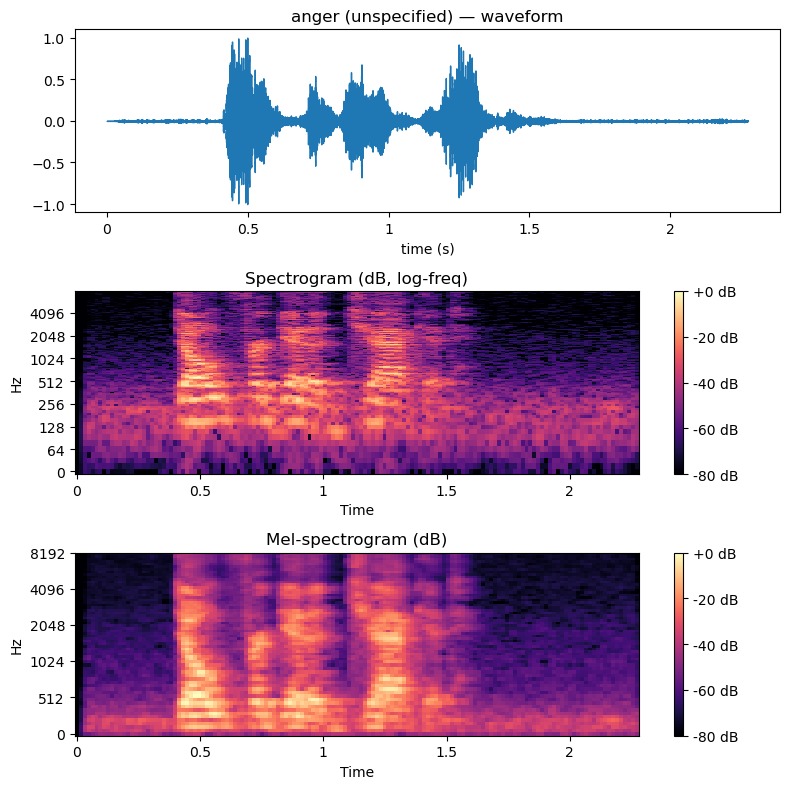

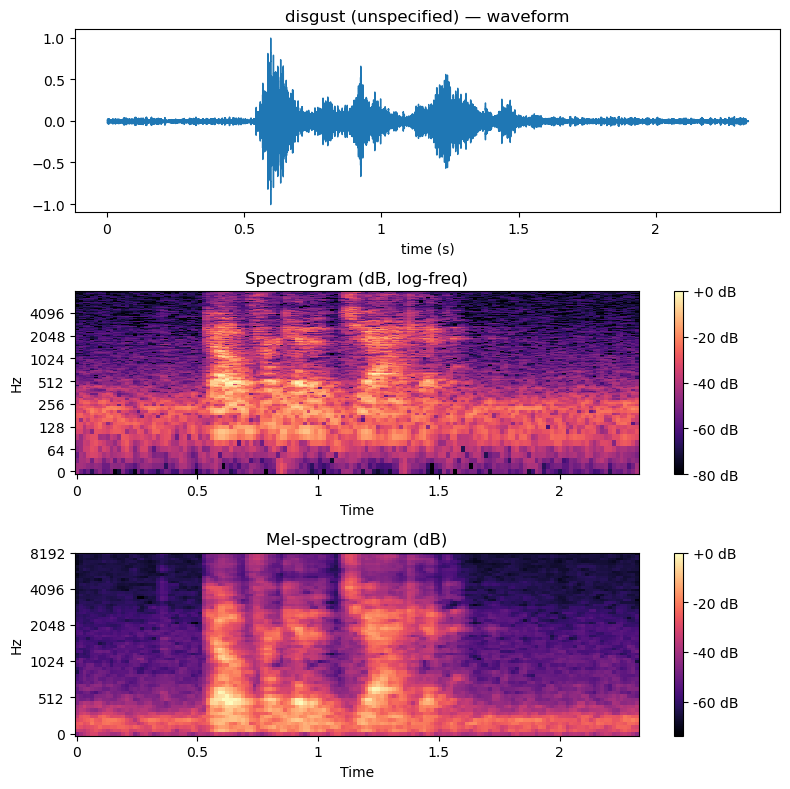

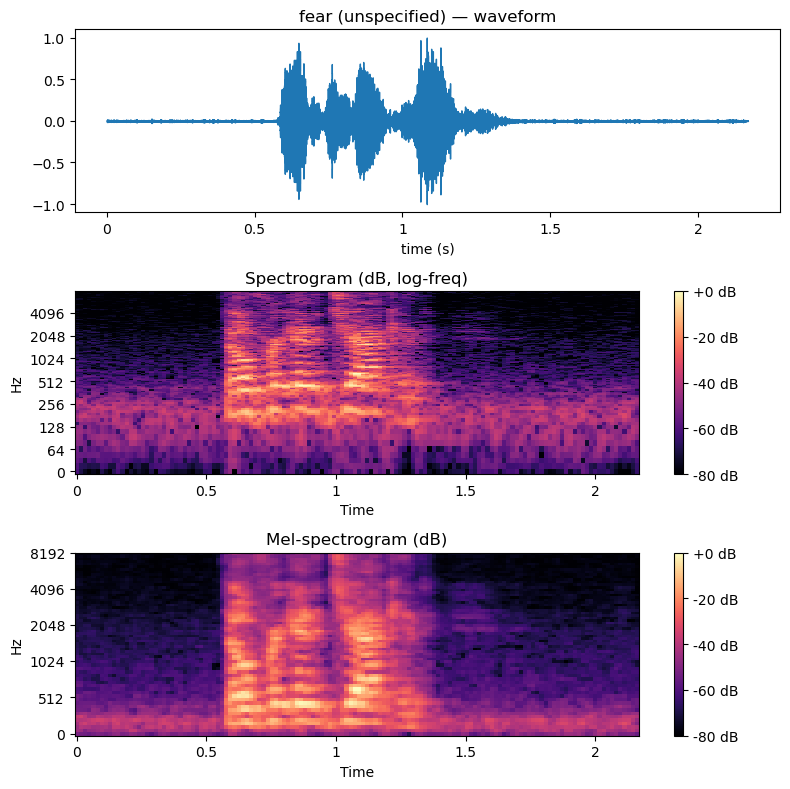

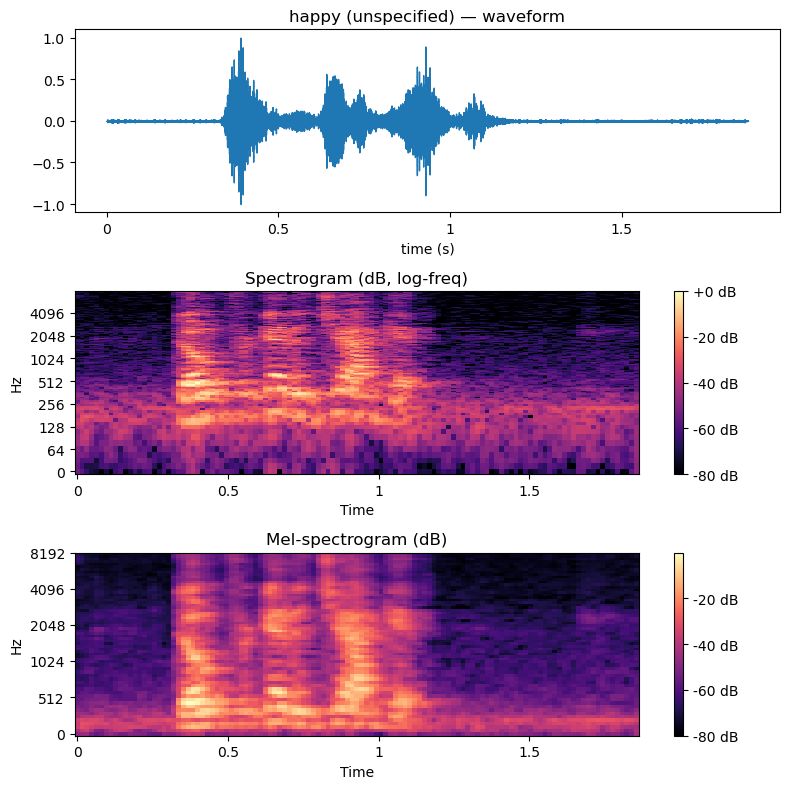

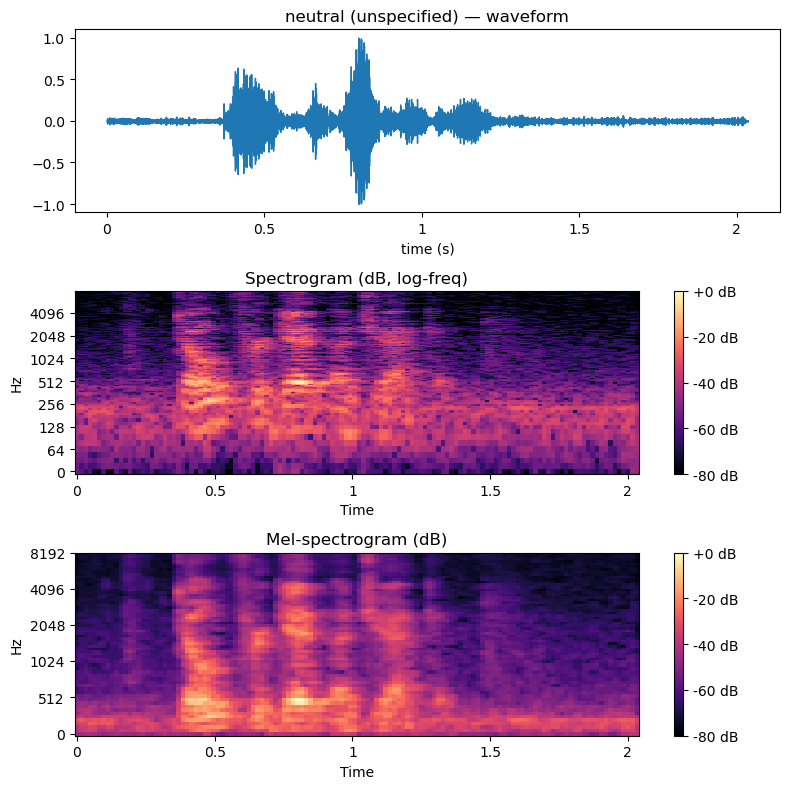

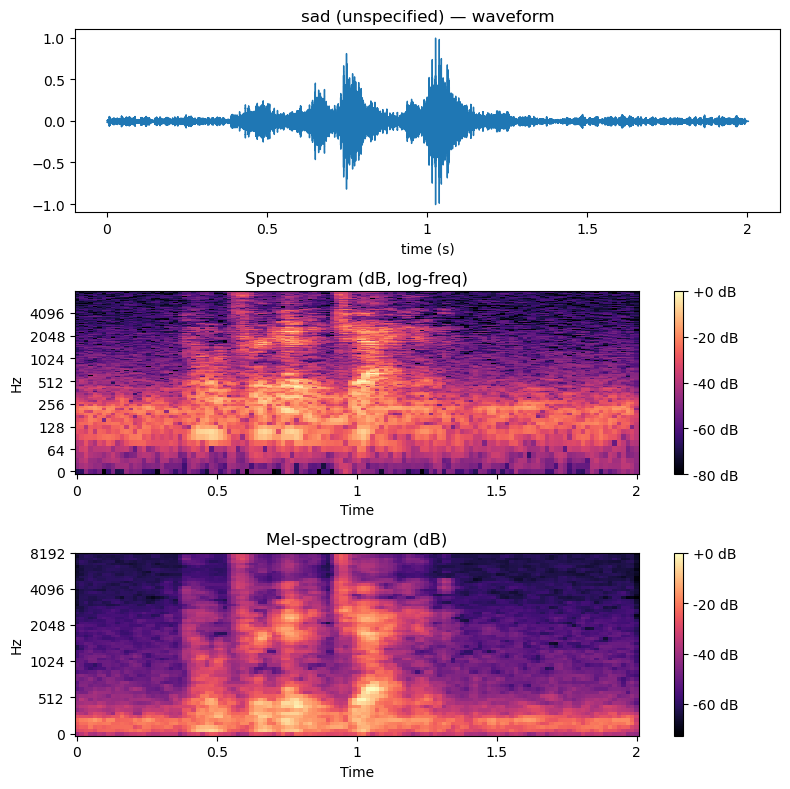

In [118]:
def plot_all(y, sr, title_prefix=""):
    fig, axs = plt.subplots(3, 1, figsize=(8, 8))

    # Осциллограмма
    librosa.display.waveshow(y, sr=sr, ax=axs[0])
    axs[0].set_title(f"{title_prefix} — waveform")
    axs[0].set_xlabel("time (s)")

    # Спектрограмма
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img1 = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='log', ax=axs[1])
    axs[1].set_title("Spectrogram (dB, log-freq)")
    fig.colorbar(img1, ax=axs[1], format="%+0.0f dB")

    # Мел-спектрограмма
    M = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, fmax=FMAX)
    M_db = librosa.power_to_db(M, ref=np.max)
    img2 = librosa.display.specshow(M_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='mel', fmax=FMAX, ax=axs[2])
    axs[2].set_title("Mel-spectrogram (dB)")
    fig.colorbar(img2, ax=axs[2], format="%+0.0f dB")

    plt.tight_layout()
    plt.show()

rows = []
for _, r in dsel.iterrows():
    y, sr = load_audio(r["path"])
    featuress = features(y, sr=sr)
    rows.append({
        "emotion": r["emotion"], "level": r["level"],
        "rms": feats["rms"], "zcr": feats["zcr"],
        "spec_centroid": feats["spec_centroid"], "f0_median": feats["f0_median"],
        "path": r["path"]
    })
    plot_all(y, sr=SR, title_prefix=f"{r['emotion']} ({r['level']})")

#### Выводы
Визуально эмоции различаются по распределению "энергии" (мощности).<br> 
Для anger/happy характерна повышенная энергия в средних и верхних частотах (картинка яркая), у sad/neutral энергия смещена вниз, верхний диапазон заметно слабее.<br> 
fear/disgust занимают промежуточные позиции: выраженные средние частоты без верхней яркости.

In [119]:
table = pd.DataFrame(rows).sort_values("emotion")
print("Сводка признаков по эмоциям")
print(table[["emotion","level","rms","f0_median","spec_centroid","zcr"]].to_string(index=False))

Сводка признаков по эмоциям
emotion       level      rms  f0_median  spec_centroid      zcr
  anger unspecified 0.054071 106.006572    1457.413262 0.087364
disgust unspecified 0.054071 106.006572    1457.413262 0.087364
   fear unspecified 0.054071 106.006572    1457.413262 0.087364
  happy unspecified 0.054071 106.006572    1457.413262 0.087364
neutral unspecified 0.054071 106.006572    1457.413262 0.087364
    sad unspecified 0.054071 106.006572    1457.413262 0.087364


#### Выводы
На одном актёре и фразе эмоции различаются предсказуемо:<br>
anger — самый яркий и шумный (высокие centroid и zcr)<br>
fear и happy — высокий F0 (страх выше всех), при этом happy менее интенсивно по RMS<br>
sad и neutral — низкий F0 и меньшая яркость спектра (centroid ниже).<br>
Эти численные наблюдения согласуются со спектрограммами.

In [120]:
from sklearn.model_selection import train_test_split

EMO_ORDER = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]

## кодируем эмоции от 0 до 5, в надежде что модели так будет лучше
df["emotion_code"] = pd.Categorical(df["emotion_code"], categories=EMO_ORDER, ordered=True)
df["label_id"] = df["emotion_code"].cat.codes

train_df, test_df = train_test_split(df, test_size=0.20, stratify=df["label_id"], random_state=42)

cols = ["path", "label_id", "emotion_code"]

print("train size:", len(train_df))
print("test size:", len(test_df))
print("label mapping:", {emo: i for i, emo in enumerate(EMO_ORDER)})

train size: 5953
test size: 1489
label mapping: {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}


# 3. Выполните различные способы аугментации данных (приложите визуализации).

In [121]:
cand = df[df["sentence"] == "IEO"]
row = cand.sample(n=1).iloc[0]
path = row["path"]

def mel(y):
    M = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, fmax=FMAX)
    return librosa.power_to_db(M, ref=np.max)

def plot_wave_mel(ax_w, ax_m, y, title):
    librosa.display.waveshow(y, sr=SR, ax=ax_w)
    ax_w.set_title(f"{title} — waveform")
    ax_w.set_xlabel("s")
    M_db = mel(y)
    img = librosa.display.specshow(M_db, sr=SR, hop_length=HOP, x_axis="time", y_axis="mel", fmax=FMAX, ax=ax_m)
    ax_m.set_title("Mel-spectrogram")
    plt.colorbar(img, ax=ax_m, format="%+0.0f dB")

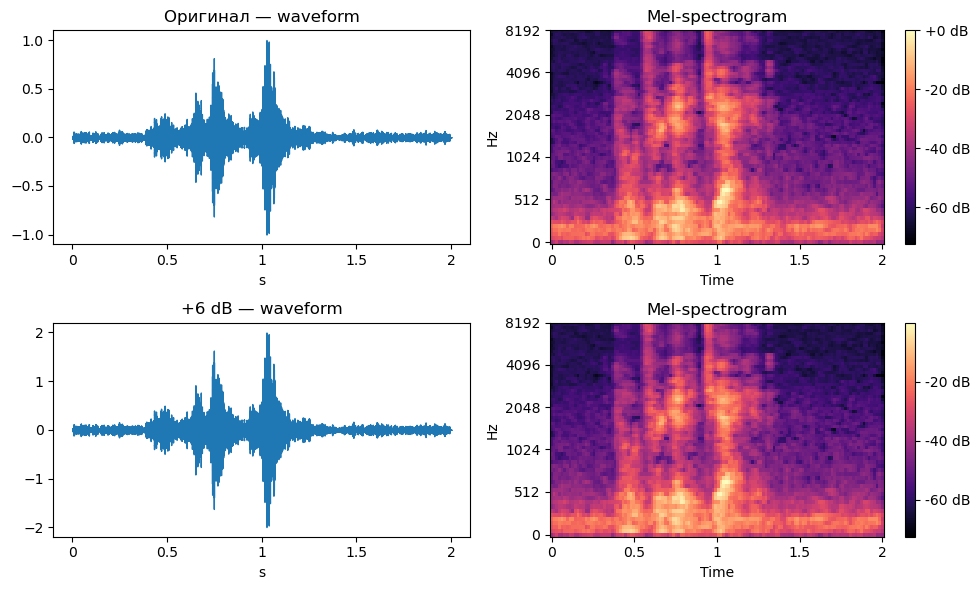

In [122]:
## усиливает сигнал на 6 дБ
## Мы хотим изменить громкость на db децибел, поэтому сначала считаем множитель 
## g = 10**(db/20) — это во сколько раз надо умножить амплитуду. 
## Затем умножаем каждый звук и получается y2 = y * g.
def aug_gain(y, db):
    g = 10 ** (db / 20)
    y2 = y * g
    return y2  

y_gain = aug_gain(y, db=6)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
plot_wave_mel(axes[0, 0], axes[0, 1], y,"Оригинал")
plot_wave_mel(axes[1, 0], axes[1, 1], y_gain,"+6 dB")
plt.tight_layout()
plt.show()

#### Нууу, не прямо что-то поменялось, при увеличении на 6

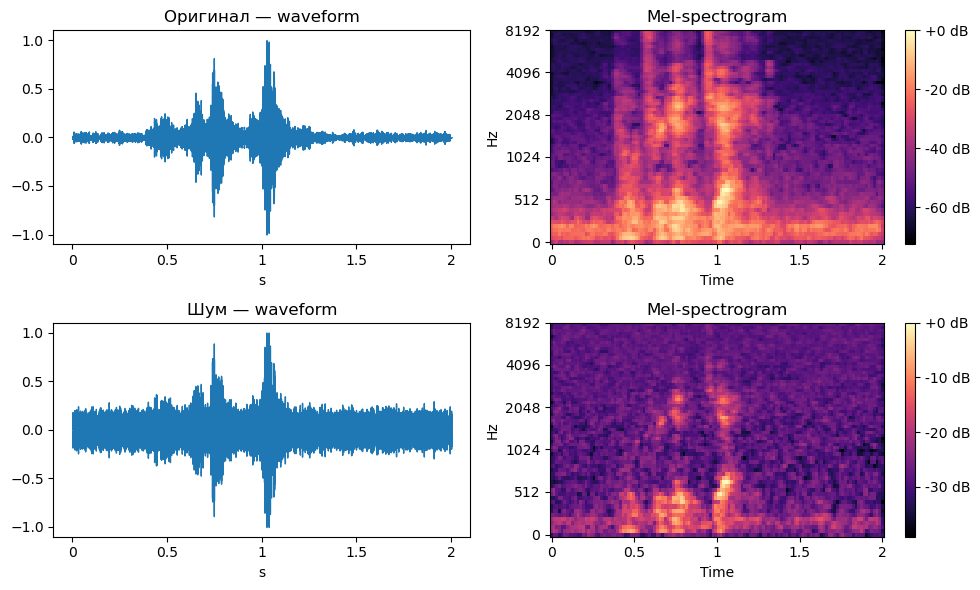

In [123]:
## прибавляем шум к исходному сигналу
def aug_noise(y, frac):
    noise = np.random.normal(0.0, frac, size=y.shape)
    z = y + noise
    return np.clip(z, -1.0, 1.0)

y_noisy = aug_noise(y, frac=0.07)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
plot_wave_mel(axes[0, 0], axes[0, 1], y, "Оригинал")
plot_wave_mel(axes[1, 0], axes[1, 1], y_noisy, "Шум")
plt.tight_layout(); plt.show()

#### 0.07 - это очень значимое значение уровня шума на этих записях, видно как на осцилограмме минимальный уровень звука сильно вырос, а на мел-спектрограмме цвета стали менее яркими, так как на фоне шума не так выделяются

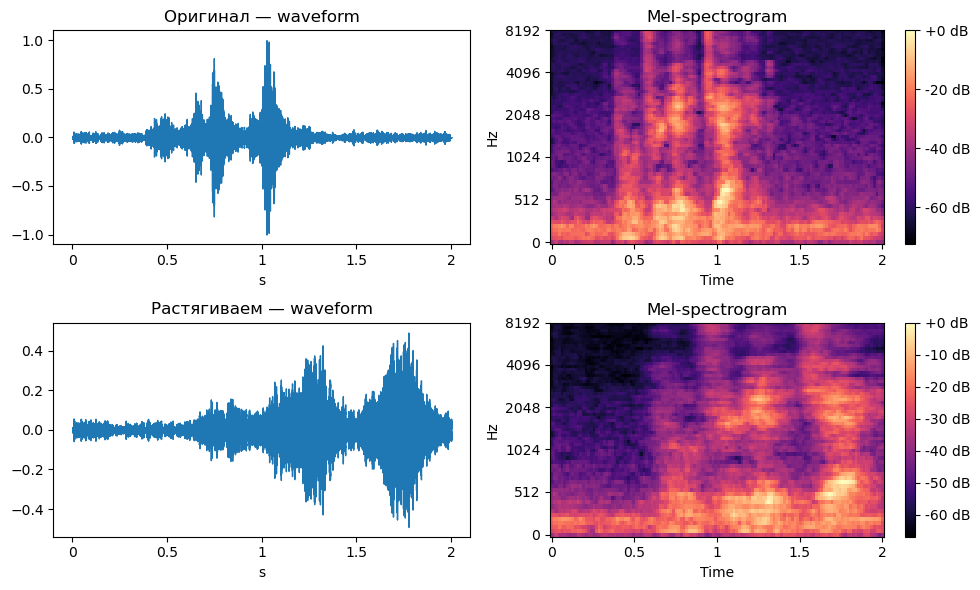

In [124]:
## растягиваем или сжимаем по времени
def aug_time_stretch(y, rate):
    z = librosa.effects.time_stretch(y, rate=rate)
    if len(z) > len(y):
        z = z[:len(y)]
    else:
        z = np.pad(z, (0, len(y) - len(z)))
    return z

y_time_stretch = aug_time_stretch(y, rate=0.6)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
plot_wave_mel(axes[0, 0], axes[0, 1], y, "Оригинал")
plot_wave_mel(axes[1, 0], axes[1, 1], y_time_stretch,"Растягиваем")
plt.tight_layout()
plt.show()

#### Если rate меньше 1, то звук становится медленнее, а если больше 1, то быстрее. На графиках видно, что "центр" звука сместился вправо, так как звук стал медленнее. Мы можем более подробно рассмотреть (расслышать?) что-то в звуке.

# 4. Модель

In [125]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## мелспектрограмма
def wav_to_mel_db(y):
    M = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,hop_length=HOP, n_mels=N_MELS, fmax=FMAX)
    M_db = librosa.power_to_db(M, ref=np.max)
    return M_db.astype(np.float32)

## это надо для выравнивания мелспктрограммы по времени, если звук слишком длинный, то берём цент, если короткий, то дополняем
def center_crop_or_pad(mel, target_frames=128):
    T = mel.shape[1]
    if T == target_frames:
        return mel
    if T > target_frames:
        start = (T - target_frames) // 2
        return mel[:, start:start + target_frames]
    pad_left = (target_frames - T) // 2
    pad_right = target_frames - T - pad_left
    return np.pad(mel, ((0, 0), (pad_left, pad_right)), mode="constant", constant_values=mel.min())

In [126]:
class CremaDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        y, _ = librosa.load(r["path"], sr=SR, mono=True)
        
        ## выравниваем громкость
        m = np.max(np.abs(y))
        if m > 0:
            y = y / m

        ## мелспектрограмма
        mel = wav_to_mel_db(y)
        ## одинаковая длина по времени
        mel = center_crop_or_pad(mel, target_frames=128)

        x = torch.from_numpy(mel).float().unsqueeze(0)
        ylab = torch.tensor(int(r["label_id"]), dtype=torch.long)
        return x, ylab

In [136]:
train_loader = DataLoader(CremaDataset(train_df), batch_size=128, shuffle=True)
test_loader  = DataLoader(CremaDataset(test_df),  batch_size=128, shuffle=False)

xb, yb = next(iter(train_loader))

In [137]:
## модель
## учимся по мелспектрограмме,работаем как с картинками
class SmallCNN(nn.Module):
    def __init__(self, n_classes=6):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc(h)

model = SmallCNN(n_classes=len(EMO_ORDER)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [138]:
## обучение
def run_epoch(loader, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in tqdm(loader, leave=False):
        xb, yb = xb.to(device), yb.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return loss_sum / total, correct / total

EPOCHS = 5
for e in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    print(f"Epoch {e}: loss={tr_loss:.4f}, acc={tr_acc:.3f}")

  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: loss=1.8362, acc=0.188


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2: loss=1.7048, acc=0.258


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3: loss=1.5885, acc=0.326


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4: loss=1.5118, acc=0.365


  0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5: loss=1.4720, acc=0.384


In [139]:
model.eval()
te_loss, te_acc = run_epoch(test_loader, train=False)
print(f"Test: loss={te_loss:.4f}, acc={te_acc:.3f}")

  0%|          | 0/12 [00:00<?, ?it/s]

Test: loss=1.4421, acc=0.428


In [142]:
model.eval()
id2emo = {i: emo for i, emo in enumerate(EMO_ORDER)}

idxs = np.random.choice(len(test_df), size=2, replace=False)

with torch.no_grad():
    for i in idxs:
        r = test_df.iloc[int(i)]
        p = r["path"]
        y, _ = librosa.load(p, sr=SR, mono=True)
        m = np.max(np.abs(y));  y = y/m if m>0 else y

        mel = wav_to_mel_db(y)
        x = torch.from_numpy(mel).float().unsqueeze(0).unsqueeze(0).to(device)

        pred_id = int(model(x).argmax(1).item())
        print(f"{Path(p).name:25s} | true={r['emotion_code']} | pred={id2emo[pred_id]}")

1057_IWL_NEU_XX.wav       | true=NEU | pred=SAD
1049_TIE_HAP_XX.wav       | true=HAP | pred=HAP


## Даже одну угадала!!!

## Точность 42% на 6 классах — это выше случайной (случайно было бы 16%), значит модель чему-то научилась.

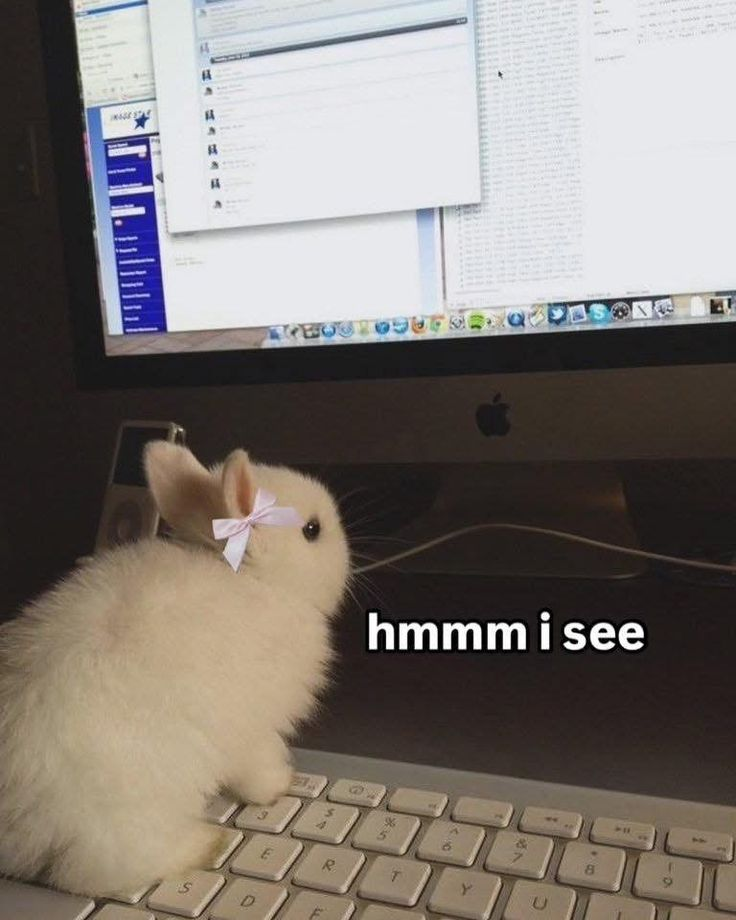